In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, average_precision_score, roc_auc_score



In [2]:
df = pd.read_csv('cleaned_data.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
X = df.drop('Class', axis=1)
y = df['Class']

X.shape, y.shape

((283726, 30), (283726,))

In [4]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    stratify=y_train_val,
    random_state=42
)


print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (181584, 30) (181584,)
Validation: (45396, 30) (45396,)
Test: (56746, 30) (56746,)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [6]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print(class_weight_dict)

{np.int64(0): np.float64(0.5008329563883893), np.int64(1): np.float64(300.63576158940396)}


In [7]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),

    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),

    layers.Dropout(0.3),

    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),

    layers.Dropout(0.3),

    layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),

    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="roc_auc"),
        keras.metrics.AUC(name="pr_auc", curve="PR")
    ]
)

In [9]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.5104 - pr_auc: 0.5376 - precision: 0.0380 - recall: 0.7815 - roc_auc: 0.8926 - val_loss: 0.2926 - val_pr_auc: 0.7609 - val_precision: 0.0301 - val_recall: 0.9211 - val_roc_auc: 0.9708
Epoch 2/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3106 - pr_auc: 0.5929 - precision: 0.0325 - recall: 0.8841 - roc_auc: 0.9681 - val_loss: 0.1881 - val_pr_auc: 0.7704 - val_precision: 0.0719 - val_recall: 0.8947 - val_roc_auc: 0.9786
Epoch 3/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2548 - pr_auc: 0.6053 - precision: 0.0425 - recall: 0.9106 - roc_auc: 0.9828 - val_loss: 0.2474 - val_pr_auc: 0.7419 - val_precision: 0.0266 - val_recall: 0.9342 - val_roc_auc: 0.9770
Epoch 4/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2262 - pr_auc: 0.6569 - precision: 0.0378 - recall: 0.9371 - roc_auc: 0.9883 - val_loss: 0.1573 - val_pr_auc: 0.7712 - val_precision: 0.0644 - val_recall: 0.9079 - val_roc_auc: 0.9760
Epoch 5/50
710

In [10]:
test_results = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

loss: 0.1382
compile_metrics: 0.0727


In [54]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [13]:
y_test_prob = model.predict(X_test_scaled).ravel()

y_test_pred = (y_test_prob >= 0.5).astype(int)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


In [14]:
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)

print(cm)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.07      0.86      0.13        95

    accuracy                           0.98     56746
   macro avg       0.54      0.92      0.56     56746
weighted avg       1.00      0.98      0.99     56746

[[55605  1046]
 [   13    82]]


In [16]:
y_val_prob = model.predict(X_val_scaled).ravel()

precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_prob
)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Best validation F1: {best_f1:.4f}")
print(f"Precision: {precision[best_index]:.4f}")
print(f"Recall: {recall[best_index]:.4f}")

1419/1419 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
Best threshold: 0.9915
Best validation F1: 0.8609
Precision: 0.8667
Recall: 0.8553


In [18]:
thresholds_to_test = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

print("Threshold | Precision | Recall | F1")
print("-" * 40)

for threshold in thresholds_to_test:
    y_pred = (y_val_prob >= threshold).astype(int)

    p = precision_score(y_val, y_pred, zero_division=0)
    r = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    print(f"{threshold:9.2f} | {p:9.3f} | {r:6.3f} | {f1:5.3f}")

Threshold | Precision | Recall | F1
----------------------------------------
     0.10 |     0.017 |  0.961 | 0.034
     0.20 |     0.027 |  0.921 | 0.053
     0.30 |     0.041 |  0.921 | 0.078
     0.40 |     0.056 |  0.908 | 0.105
     0.50 |     0.077 |  0.895 | 0.141
     0.60 |     0.120 |  0.882 | 0.211
     0.70 |     0.206 |  0.882 | 0.334
     0.80 |     0.362 |  0.882 | 0.513
     0.90 |     0.663 |  0.882 | 0.757


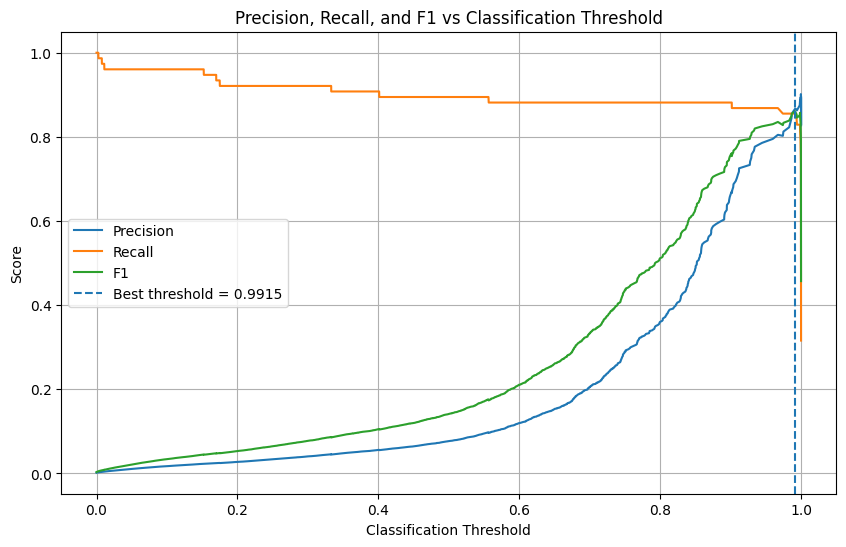

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1")

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.4f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs Classification Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
THRESHOLD = best_threshold

y_test_pred_tuned = (
    y_test_prob >= THRESHOLD
).astype(int)

In [21]:
print(classification_report(
    y_test,
    y_test_pred_tuned,
    target_names=["Legitimate", "Fraud"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_tuned))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.87      0.75      0.80        95

    accuracy                           1.00     56746
   macro avg       0.93      0.87      0.90     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56640    11]
 [   24    71]]


# hyperparameter tuning

In [23]:
def build_model(
    hidden_units=(64, 32, 16),
    dropout_rate=0.3,
    l2_strength=0.001,
    learning_rate=0.001
):
    model = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],))
    ])

    for units in hidden_units:
        model.add(
            layers.Dense(units, activation="relu", kernel_regularizer=regularizers.l2(l2_strength))
        )
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="roc_auc"),
            keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    return model

In [24]:
experiments = {
    "Baseline": {
        "hidden_units": (64, 32, 16),
        "dropout_rate": 0.30,
        "l2_strength": 0.001,
        "learning_rate": 0.001
    },

    "Larger Network": {
        "hidden_units": (128, 64, 32),
        "dropout_rate": 0.30,
        "l2_strength": 0.001,
        "learning_rate": 0.001
    },

    "Lower Dropout": {
        "hidden_units": (64, 32, 16),
        "dropout_rate": 0.20,
        "l2_strength": 0.001,
        "learning_rate": 0.001
    },

    "Higher Dropout": {
        "hidden_units": (64, 32, 16),
        "dropout_rate": 0.40,
        "l2_strength": 0.001,
        "learning_rate": 0.001
    },

    "Lower L2": {
        "hidden_units": (128, 64, 32),
        "dropout_rate": 0.30,
        "l2_strength": 0.0001,
        "learning_rate": 0.001
    }
}

In [25]:
results = []

for name, params in experiments.items():

    print(f"\nTraining: {name}")

    experiment_model = build_model(**params)

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=5,
        restore_best_weights=True
    )

    history = experiment_model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=50,
        batch_size=256,
        class_weight=class_weight_dict,
        callbacks=[early_stopping],
        verbose=0
    )

    best_val_pr_auc = max(history.history["val_pr_auc"])
    best_val_roc_auc = max(history.history["val_roc_auc"])

    results.append({
        "Model": name,
        "Best Val PR-AUC": best_val_pr_auc,
        "Best Val ROC-AUC": best_val_roc_auc,
        "Epochs": len(history.history["loss"])
    })

    print(f"Best Val PR-AUC: {best_val_pr_auc:.4f}")
    print(f"Best Val ROC-AUC: {best_val_roc_auc:.4f}")
    print(f"Epochs: {len(history.history['loss'])}")


Training: Baseline
Best Val PR-AUC: 0.7749
Best Val ROC-AUC: 0.9834
Epochs: 13

Training: Larger Network
Best Val PR-AUC: 0.7641
Best Val ROC-AUC: 0.9793
Epochs: 11

Training: Lower Dropout
Best Val PR-AUC: 0.7906
Best Val ROC-AUC: 0.9771
Epochs: 11

Training: Higher Dropout
Best Val PR-AUC: 0.7806
Best Val ROC-AUC: 0.9781
Epochs: 11

Training: Lower L2
Best Val PR-AUC: 0.7776
Best Val ROC-AUC: 0.9777
Epochs: 11


In [26]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "Best Val PR-AUC",
    ascending=False
)

,Model,Best Val PR-AUC,Best Val ROC-AUC,Epochs
2,Lower Dropout,0.790615,0.977075,11
3,Higher Dropout,0.780640,0.978077,11
4,Lower L2,0.777578,0.977731,11
0,Baseline,0.774866,0.983425,13
1,Larger Network,0.764095,0.979302,11


In [44]:
best_config = experiments[results_df.sort_values("Best Val PR-AUC", ascending=False).iloc[0]['Model']]

best_config

{'hidden_units': (64, 32, 16),
 'dropout_rate': 0.2,
 'l2_strength': 0.001,
 'learning_rate': 0.001}

In [45]:
final_model = build_model(
    hidden_units=best_config['hidden_units'],
    dropout_rate=best_config['dropout_rate'],
    l2_strength=best_config['l2_strength'],
    learning_rate=best_config['learning_rate']
)

In [46]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=5,
    restore_best_weights=True
)

final_history = final_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.4198 - pr_auc: 0.5223 - precision: 0.0347 - recall: 0.8013 - roc_auc: 0.9268 - val_loss: 0.2652 - val_pr_auc: 0.7605 - val_precision: 0.0352 - val_recall: 0.9079 - val_roc_auc: 0.9775
Epoch 2/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2614 - pr_auc: 0.6091 - precision: 0.0376 - recall: 0.9106 - roc_auc: 0.9807 - val_loss: 0.1723 - val_pr_auc: 0.7270 - val_precision: 0.0587 - val_recall: 0.8947 - val_roc_auc: 0.9789
Epoch 3/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2275 - pr_auc: 0.6037 - precision: 0.0417 - recall: 0.9238 - roc_auc: 0.9876 - val_loss: 0.1443 - val_pr_auc: 0.7336 - val_precision: 0.0814 - val_recall: 0.8947 - val_roc_auc: 0.9769
Epoch 4/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.2239 - pr_auc: 0.5874 - precision: 0.0388 - recall: 0.9305 - roc_auc: 0.9875 - val_loss: 0.1725 - val_pr_auc: 0.7364 - val_precision: 0.0447 - val_recall: 0.9211 - val_roc_auc: 0.9741
Epoch 5/50
710

In [47]:
print(
    "Best validation PR-AUC:",
    max(final_history.history["val_pr_auc"])
)

print(
    "Best validation ROC-AUC:",
    max(final_history.history["val_roc_auc"])
)

print(
    "Epochs trained:",
    len(final_history.history["loss"])
)

Best validation PR-AUC: 0.7656034827232361
Best validation ROC-AUC: 0.9789144992828369
Epochs trained: 10


In [48]:
y_val_prob_final = final_model.predict(X_val_scaled).ravel()

precision_final, recall_final, thresholds_final = precision_recall_curve(
    y_val,
    y_val_prob_final
)

f1_final = (
    2 * precision_final * recall_final /
    (precision_final + recall_final + 1e-8)
)

best_idx_final = np.argmax(f1_final)

final_threshold = thresholds_final[best_idx_final]

print(f"Final threshold: {final_threshold:.4f}")
print(f"Validation Precision: {precision_final[best_idx_final]:.4f}")
print(f"Validation Recall: {recall_final[best_idx_final]:.4f}")
print(f"Validation F1: {f1_final[best_idx_final]:.4f}")

1419/1419 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Final threshold: 0.9956
Validation Precision: 0.8667
Validation Recall: 0.8553
Validation F1: 0.8609


In [49]:
y_test_prob_final = final_model.predict(X_test_scaled).ravel()

y_test_pred_final = (
    y_test_prob_final >= final_threshold
).astype(int)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [50]:
print(classification_report(
    y_test,
    y_test_pred_final,
    target_names=["Legitimate", "Fraud"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_final))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.87      0.75      0.80        95

    accuracy                           1.00     56746
   macro avg       0.93      0.87      0.90     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56640    11]
 [   24    71]]


# final graphs

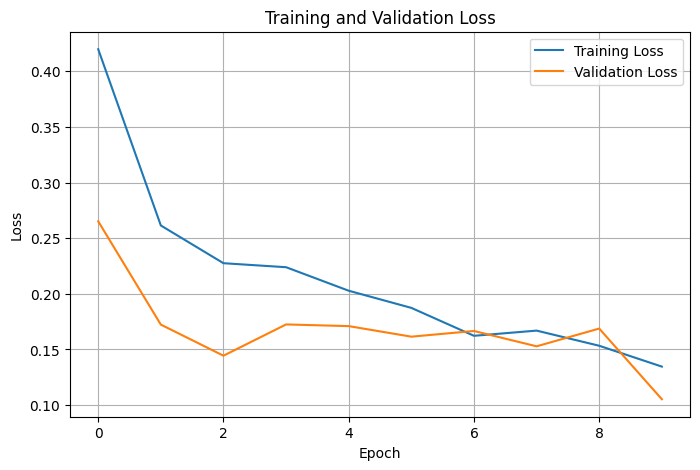

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

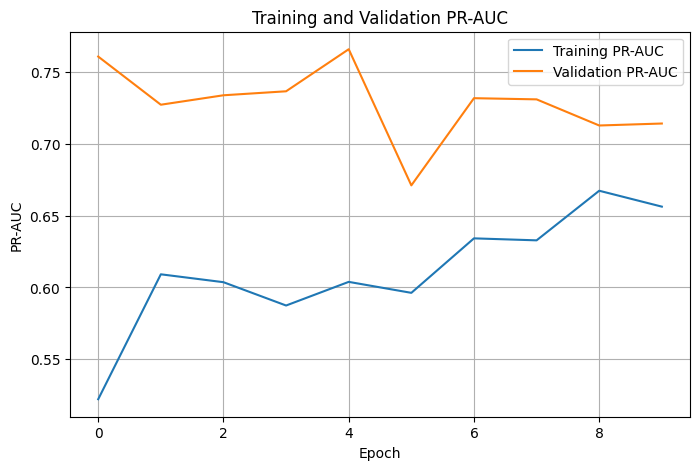

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["pr_auc"],
    label="Training PR-AUC"
)

plt.plot(
    final_history.history["val_pr_auc"],
    label="Validation PR-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("Training and Validation PR-AUC")
plt.legend()
plt.grid(True)
plt.show()

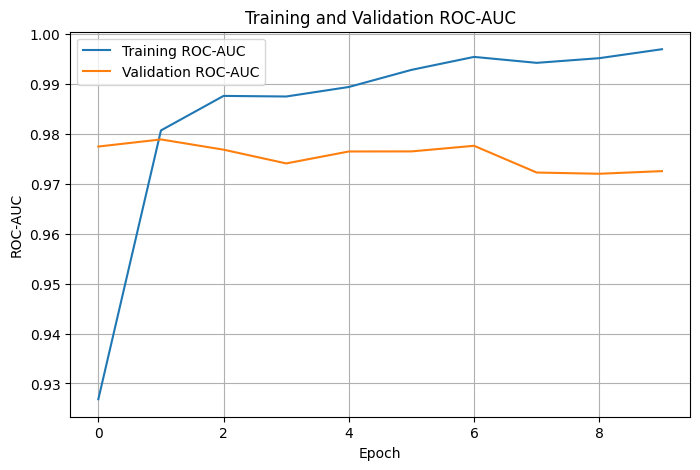

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["roc_auc"],
    label="Training ROC-AUC"
)

plt.plot(
    final_history.history["val_roc_auc"],
    label="Validation ROC-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Training and Validation ROC-AUC")
plt.legend()
plt.grid(True)
plt.show()

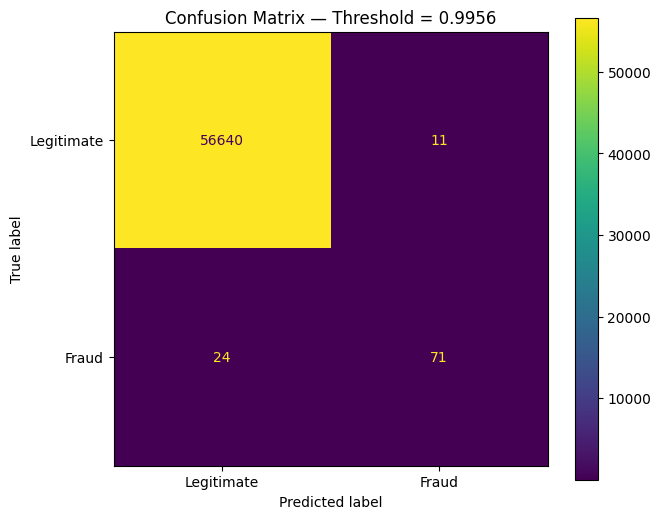

In [55]:
cm = confusion_matrix(
    y_test,
    y_test_pred_final
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    f"Confusion Matrix — Threshold = {final_threshold:.4f}"
)

plt.show()

In [64]:
final_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred_final),
    "Precision": precision_score(y_test, y_test_pred_final),
    "Recall": recall_score(y_test, y_test_pred_final),
    "F1 Score": f1_score(y_test, y_test_pred_final),
    "PR-AUC": average_precision_score(
    y_test,
    y_test_prob_final
),
    "ROC-AUC": roc_auc_score(
    y_test,
    y_test_prob_final
)

}

final_metrics_df = pd.DataFrame(
    final_metrics.items(),
    columns=["Metric", "Value"]
)

final_metrics_df

,Metric,Value
0,Accuracy,0.999383
1,Precision,0.865854
2,Recall,0.747368
3,F1 Score,0.802260
4,PR-AUC,0.686745
5,ROC-AUC,0.964181


# saving the the work

In [67]:
import os

os.makedirs("artifacts", exist_ok=True)

In [68]:
final_model.save("artifacts/fraud_detection_model.keras")

In [69]:
import joblib

joblib.dump(
    scaler,
    "artifacts/scaler.pkl"
)

['artifacts/scaler.pkl']

In [70]:
import json

with open("artifacts/threshold.json", "w") as f:
    json.dump(
        {
            "threshold": float(final_threshold)
        },
        f,
        indent=4
    )

In [71]:
with open("artifacts/model_config.json", "w") as f:
    json.dump(
        {
            "hidden_units": list(best_config["hidden_units"]),
            "dropout_rate": best_config["dropout_rate"],
            "l2_strength": best_config["l2_strength"],
            "learning_rate": best_config["learning_rate"],
            "batch_size": 256,
            "selected_threshold": float(final_threshold)
        },
        f,
        indent=4
    )

In [72]:
final_metrics_df.to_csv(
    "artifacts/final_metrics.csv",
    index=False
)

In [73]:
results_df.to_csv(
    "artifacts/hyperparameter_results.csv",
    index=False
)

In [74]:
history_df = pd.DataFrame(final_history.history)

history_df.to_csv(
    "artifacts/training_history.csv",
    index=False
)